<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Grade              862 non-null    object 
 1   Project            862 non-null    object 
 2   Case_ID            862 non-null    object 
 3   Gender             862 non-null    object 
 4   Age_at_diagnosis   862 non-null    object 
 5   Primary_Diagnosis  862 non-null    object 
 6   Race               862 non-null    object 
 7   IDH1               862 non-null    int64  
 8   TP53               862 non-null    int64  
 9   ATRX               862 non-null    int64  
 10  PTEN               862 non-null    int64  
 11  EGFR               862 non-null    int64  
 12  CIC                862 non-null    int64  
 13  MUC16              862 non-null    int64  
 14  PIK3CA             862 non-null    int64  
 15  NF1                862 non-null    int64  
 16  PIK3R1             862 non

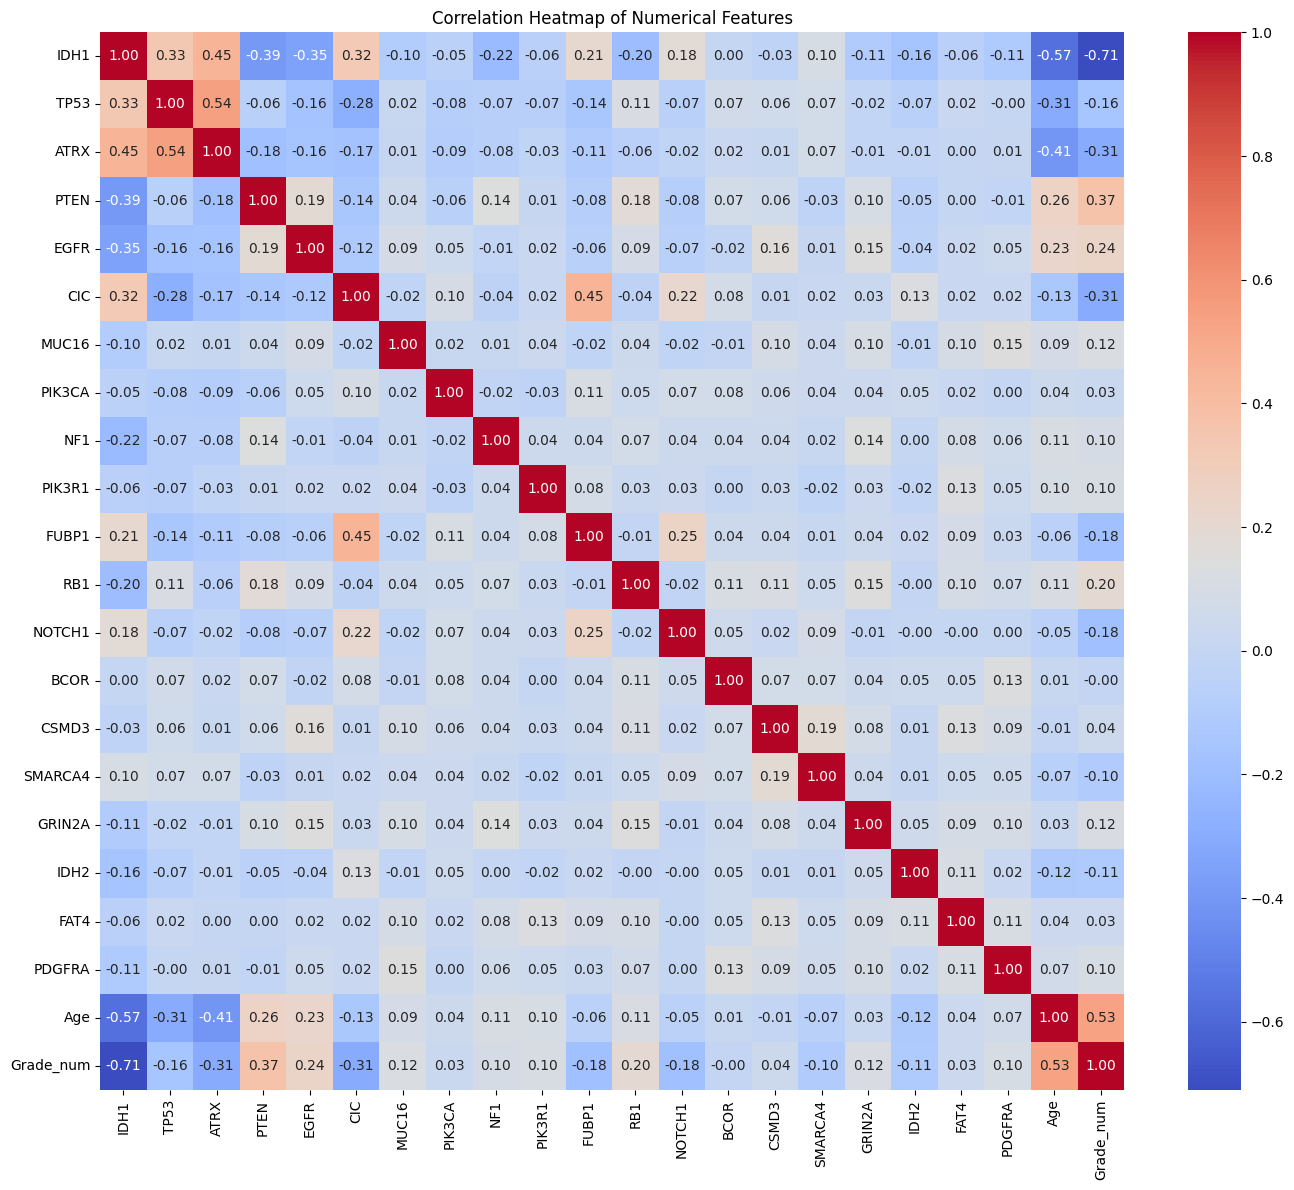

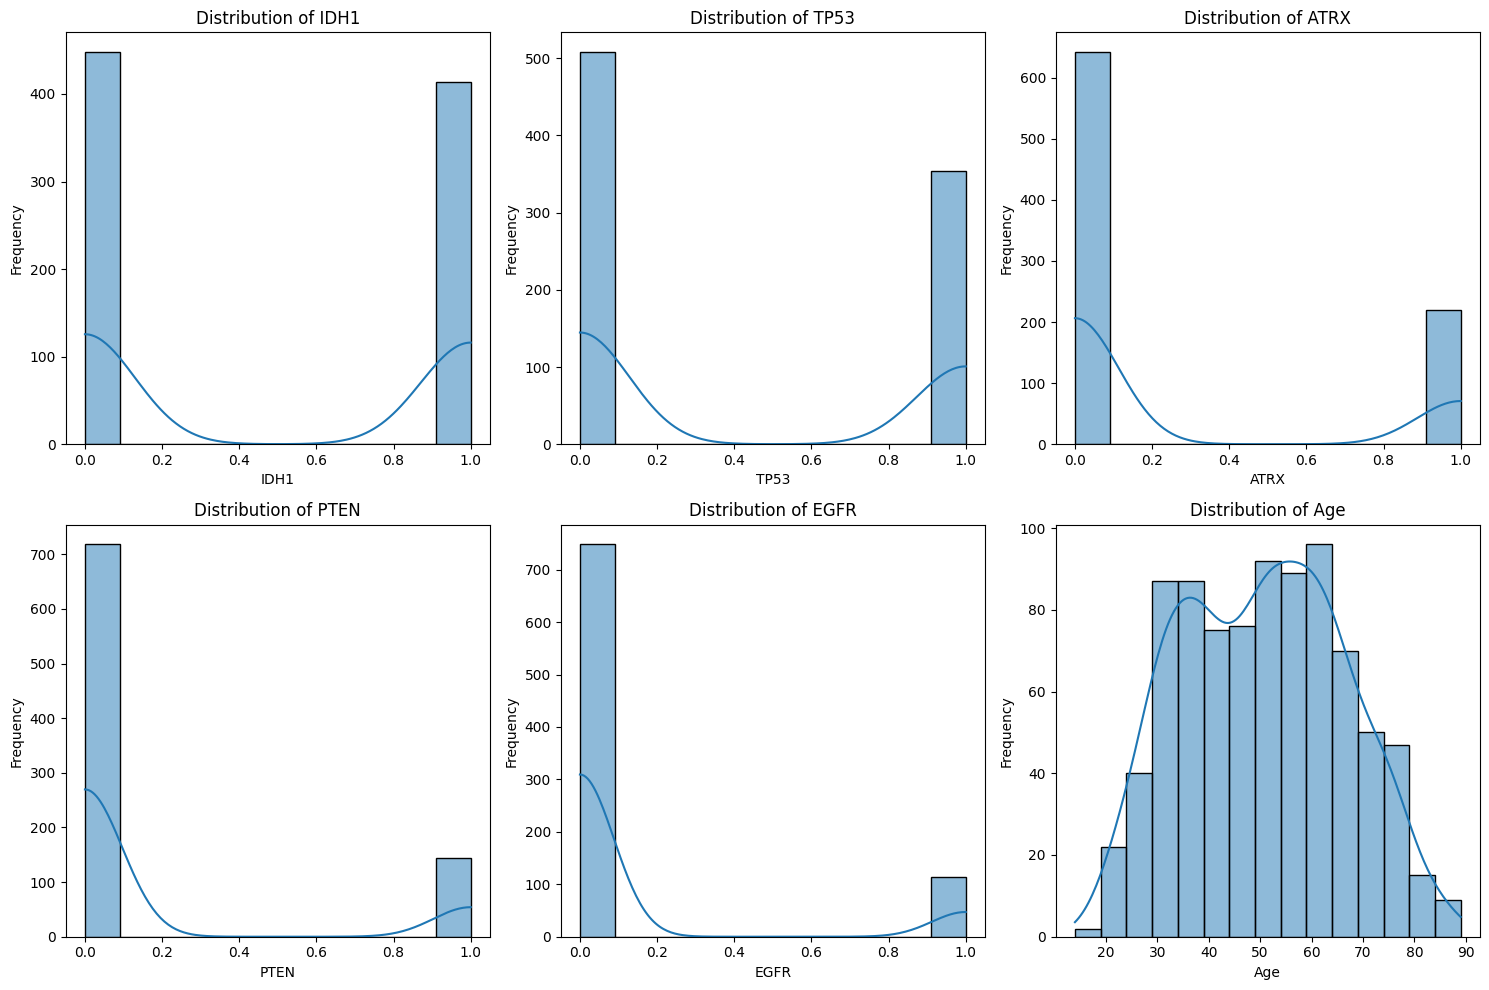

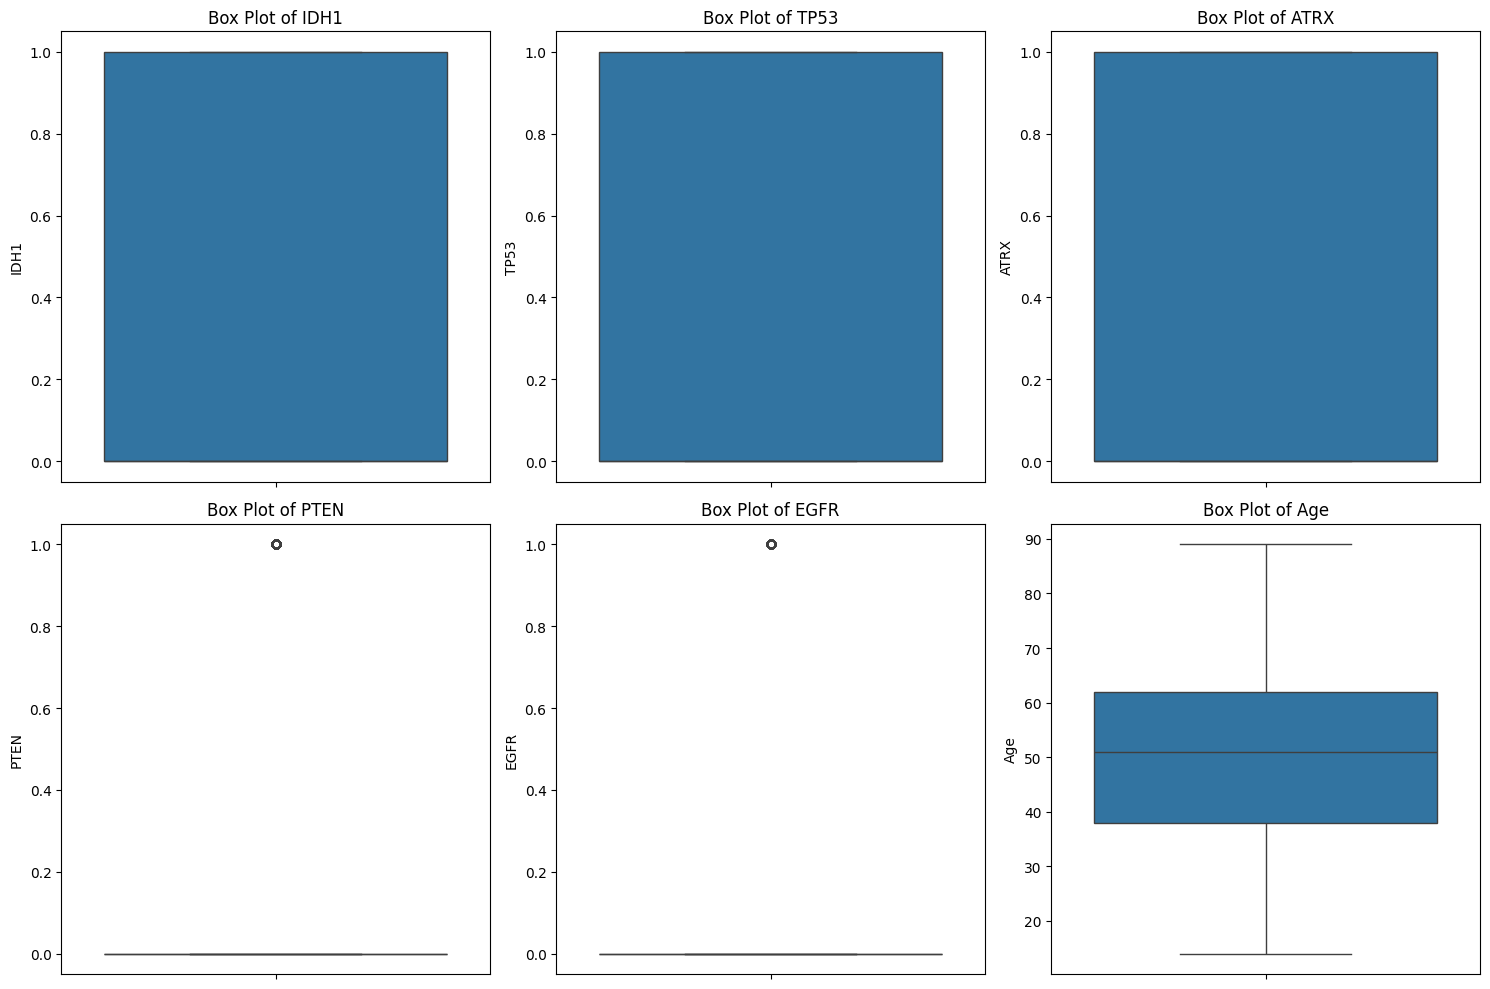

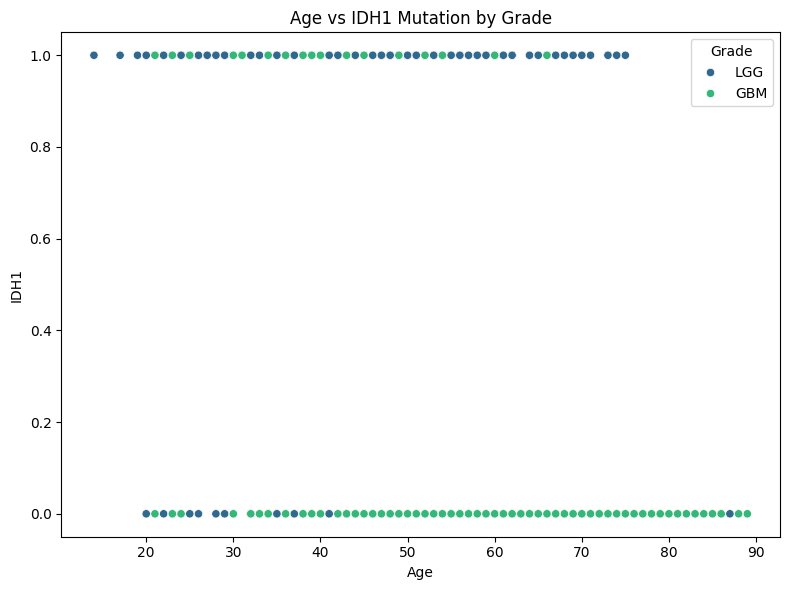

/tmp/ipykernel_21456/2482980579.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=df, palette='Set2')


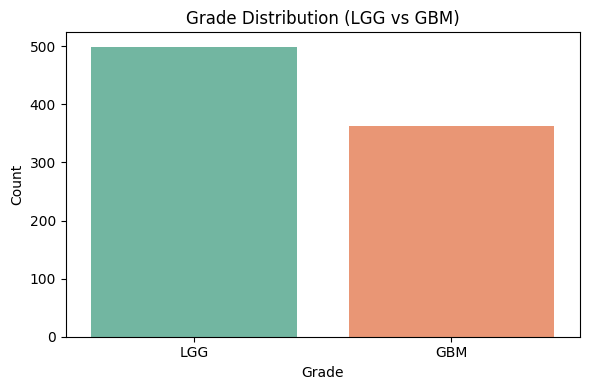

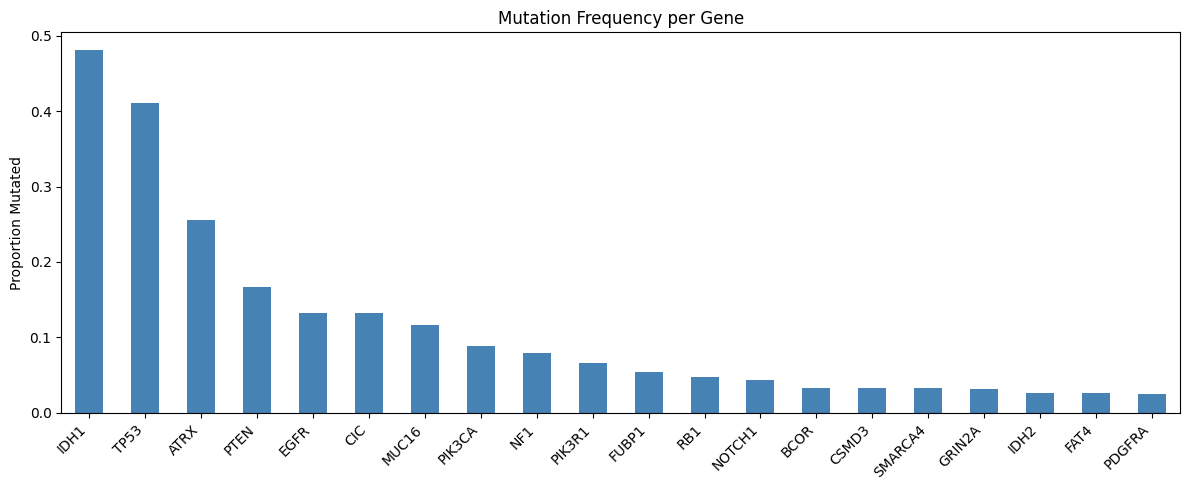

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ── Helper & constants ──────────────────────────────────────────
def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# ── Load Data ───────────────────────────────────────────────────
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)
df['Grade_num'] = (df['Grade'] == 'GBM').astype(int)
df.info()

# ── Correlation Heatmap ─────────────────────────────────────────
numerical_features = mut_cols + ['Age', 'Grade_num']
correlation_matrix = df[numerical_features].dropna().corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# ── Histograms ──────────────────────────────────────────────────
numerical_cols_hist = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'Age']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_hist):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ── Box Plots ───────────────────────────────────────────────────
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_hist):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# ── Scatter Plot: Age vs IDH1 colored by Grade ─────────────────
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='IDH1', hue='Grade', palette='viridis')
plt.title('Age vs IDH1 Mutation by Grade')
plt.tight_layout()
plt.show()

# ── Grade Distribution (Count Plot) ────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x='Grade', data=df, palette='Set2')
plt.title('Grade Distribution (LGG vs GBM)')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ── Mutation Frequency per Gene ─────────────────────────────────
mutation_freq = df[mut_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
mutation_freq.plot(kind='bar', color='steelblue')
plt.title('Mutation Frequency per Gene')
plt.ylabel('Proportion Mutated')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful